# Parameter estimation results

This notebook inspects the results from the various parameter estimation runs.


---

In [3]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import corner
import sys


def diagnostics(fname):
    inf_data = az.from_netcdf(fname)
    print(f"Successfully loaded InferenceData from: {fname}")


    # --- 1. Get Full Summary ---
    print("\n--- Calculating Full MCMC Summary ---")
    # Calculate summary for ALL variables first
    full_summary_df = az.summary(inf_data, kind='all', round_to=3, hdi_prob=0.94) # Using default HDI

    # print(full_summary_df['sd'])



    # --- 2. Filter out Constant Deterministic Variables ---
    # Identify variables with near-zero standard deviation (likely constants)
    # Use a small tolerance instead of exact zero for floating point comparisons
    tolerance = 1e-12
    is_sampled_or_derived = full_summary_df['sd'] > tolerance
    sampled_summary_df = full_summary_df[is_sampled_or_derived]

    print("\n--- Filtered MCMC Summary (Excluding Constant Deterministics) ---")
    if sampled_summary_df.empty:
        print("Warning: No variables with standard deviation > tolerance found. Check model or tolerance.")
    else:
        print(sampled_summary_df)

    # --- 3. Diagnostics on Filtered Parameters ---
    if not sampled_summary_df.empty:
        print("\n--- Interpretation Guidance (Filtered Parameters) ---")
        print("Checking R-hat and ESS only for variables that showed variation:")
        # Check R-hat
        max_rhat = sampled_summary_df['r_hat'].max()
        print(f"\nMaximum R-hat value (filtered): {max_rhat:.3f}")
        if max_rhat > 1.05:
            print("WARNING: Maximum R-hat is high (> 1.05), suggesting potential convergence issues. Consider increasing 'num_warmup'.")
        elif max_rhat > 1.01:
            print("NOTE: Maximum R-hat is slightly elevated (> 1.01). Check trace plots carefully.")
        else:
            print("R-hat values look good (<= 1.01).")

        # Check ESS
        min_ess_bulk = sampled_summary_df['ess_bulk'].min()
        min_ess_tail = sampled_summary_df['ess_tail'].min()
        print(f"Minimum Bulk ESS (filtered): {min_ess_bulk:.0f}")
        print(f"Minimum Tail ESS (filtered): {min_ess_tail:.0f}")
        if min_ess_bulk < 400 or min_ess_tail < 400:
            print("WARNING: Minimum ESS is low (< 400). Consider increasing 'num_samples'.")
        else:
            print("ESS values look sufficient (>= 400).")

        # --- 4. Trace Plots for Filtered Parameters ---
        print("\n--- Generating Trace Plots (Filtered Parameters) ---")
        # Get the names of the variables to plot from the filtered summary index
        var_names_to_plot = sampled_summary_df.index.tolist()

        if var_names_to_plot:
            try:
                trace_plot = az.plot_trace(inf_data, var_names=var_names_to_plot, compact=True)
                plt.tight_layout()
                print("Displaying trace plots...")
                plt.show()
            except Exception as e:
                print(f"Could not generate trace plots: {e}")
        else:
            print("No variables left to plot after filtering.")

        print("\n--- Trace Plot Interpretation ---")
        print("(Interpret as before, focusing on these non-constant variables)")

    else:
        print("\nSkipping detailed diagnostics as no non-constant parameters were found in the summary.")


    # --- 5. Divergent Transitions (Applies to the whole sampler run) ---
    # This check remains the same as it reflects the sampler's overall behavior
    print("\n--- Checking for Divergent Transitions ---")
    if "sample_stats" in inf_data and "diverging" in inf_data.sample_stats:
        # ... (rest of divergence check code is identical to previous version) ...
        divergences = inf_data.sample_stats["diverging"].sum().item() # .item() gets scalar value
        total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]
        print(f"Total number of divergent transitions: {divergences}")
        print(f"Total post-warmup samples: {total_samples}")
        if divergences > 0:
            divergence_rate = (divergences / total_samples) * 100
            print(f"Divergence rate: {divergence_rate:.2f}%")
            print("WARNING: Divergences indicate potential issues exploring the posterior.")
            print("Consider:")
            print("  1. Model Reparameterization (e.g., non-centered parameterization).")
            print("  2. Increasing 'target_accept_prob' in the NUTS kernel (e.g., kernel = NUTS(model, target_accept_prob=0.90 or 0.95)).")
            print("  3. Using stronger priors if appropriate.")
        else:
            print("No divergent transitions found. Good!")
    else:
        print("Divergence information not found in sample_stats.")


    print("\n--- Diagnostics Complete ---")

def posterior_plot(data_file,parameters,log_scale,ranges):
    # Load data
    data = az.from_netcdf(data_file)
    
    # Validate input lists have same length
    if not (len(parameters) == len(ranges) == len(log_scale)):
        raise ValueError("parameters, ranges and log_scale lists must have same length")
        
    # Get samples for each parameter
    samples = []
    for param in parameters:
        if param not in data.posterior:
            raise ValueError(f"Parameter {param} not found in data")
        samples.append(data.posterior[param].values.flatten())
    
    samples = np.column_stack(samples)
    
    # Apply log transform where specified and adjust ranges accordingly
    for i, (param, do_log) in enumerate(zip(parameters, log_scale)):
        if do_log:
            samples[:,i] = np.log10(samples[:,i])
            parameters[i] = f"log({param})"
            ranges[i] = (np.log10(ranges[i][0]), np.log10(ranges[i][1]))


    print("the ranges are:", ranges)

    # Create corner plot
    fig = corner.corner(
        samples,
        labels=['log(ha)'],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=ranges,
        bins=30,  # Adjust number of bins as needed
        smooth=1.0,  # Adjust smoothing as needed
        plot_datapoints=True,
        fill_contours=True,
        levels=[0.68, 0.95]  # 1 and 2 sigma contours
    )

    plt.tight_layout()
    plt.show()





# 1. MDC2, dataset iib. Just $h_a$

Successfully loaded InferenceData from: ../sandbox/outputs/mdc2_parameter_estimation_NUTS_results_2025-04-26_16-49-52.nc

--- Calculating Full MCMC Summary ---


/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)



--- Filtered MCMC Summary (Excluding Constant Deterministics) ---
            mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log10_ha -15.462  0.06 -15.584  -15.356      0.002    0.001  1275.848   

          ess_tail  r_hat  
log10_ha   972.416    1.0  

--- Interpretation Guidance (Filtered Parameters) ---
Checking R-hat and ESS only for variables that showed variation:

Maximum R-hat value (filtered): 1.000
R-hat values look good (<= 1.01).
Minimum Bulk ESS (filtered): 1276
Minimum Tail ESS (filtered): 972
ESS values look sufficient (>= 400).

--- Generating Trace Plots (Filtered Parameters) ---
Displaying trace plots...


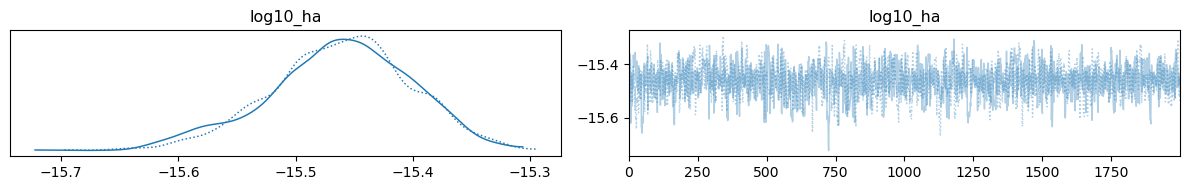


--- Trace Plot Interpretation ---
(Interpret as before, focusing on these non-constant variables)

--- Checking for Divergent Transitions ---
Total number of divergent transitions: 0
Total post-warmup samples: 4000
No divergent transitions found. Good!

--- Diagnostics Complete ---
the ranges are: [(-16.0, -14.0)]


/tmp/ipykernel_2546942/2406551971.py:88: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]


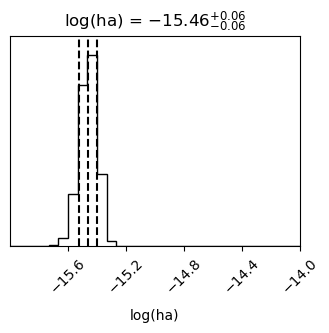

In [4]:
#fname = '../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_13-12-25.nc'
#fname = '../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_15-17-53.nc'
fname = '../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_15-55-58.nc'
fname = '../sandbox/outputs/mdc2_parameter_estimation_NUTS_results_2025-04-25_17-04-24.nc'
fname = '../sandbox/outputs/mdc2_parameter_estimation_NUTS_results_2025-04-26_16-49-52.nc'
diagnostics(fname)


posterior_plot(fname,parameters=['ha'],log_scale=[True],ranges=[(1e-16, 1e-14)])

<Axes: title={'center': 'log10_ha'}>

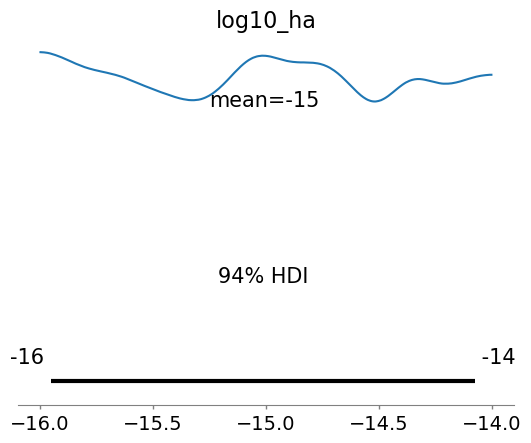

In [21]:
fname = '../sandbox/outputs/mdc2_parameter_estimation_NUTS_results_2025-04-25_17-04-24.nc'
data = az.from_netcdf(fname)
az.plot_posterior(data, var_names=['log10_ha'])


# Diagnostics 

Successfully loaded InferenceData from: ../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_13-12-25.nc

--- Calculating Full MCMC Summary ---


/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)



--- Filtered MCMC Summary (Excluding Constant Deterministics) ---
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log10_ha -15.098  0.356 -15.557  -14.646      0.177    0.136     4.361   

          ess_tail  r_hat  
log10_ha    10.455  3.698  

--- Interpretation Guidance (Filtered Parameters) ---
Checking R-hat and ESS only for variables that showed variation:

Maximum R-hat value (filtered): 3.698
Minimum Bulk ESS (filtered): 4
Minimum Tail ESS (filtered): 10

--- Generating Trace Plots (Filtered Parameters) ---
Displaying trace plots...


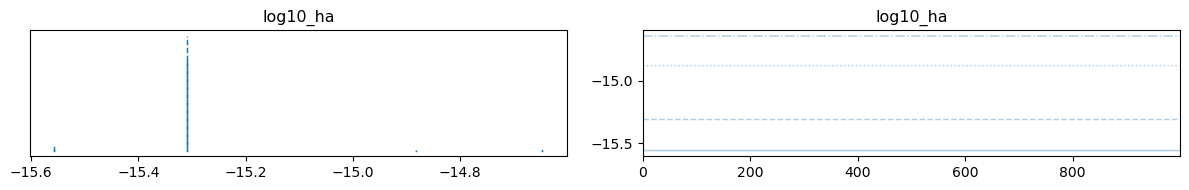


--- Trace Plot Interpretation ---
(Interpret as before, focusing on these non-constant variables)

--- Checking for Divergent Transitions ---
Total number of divergent transitions: 0
Total post-warmup samples: 4000
No divergent transitions found. Good!

--- Diagnostics Complete ---


/tmp/ipykernel_3929949/1780386334.py:111: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]


In [6]:
fname = '../sandbox/outputs/mdc3_parameter_estimation_results_2025-04-25_13-12-25.nc'
diagnostics(fname)

In [7]:
data = az.from_netcdf(fname)

samples = np.column_stack([
    data.posterior['ha'].values.flatten()
])

print("Mean of selected parameters:")
print(data.posterior['ha'].mean())

# Transform to log space
log_samples = np.log10(samples)

# Set plot limits (adjust these values based on your data)
ranges = [
    (-14, -10),  # ha limits
]

Mean of selected parameters:
<xarray.DataArray 'ha' ()> Size: 8B
array(1.08489843e-15)


In [16]:
y = data.posterior['ha'].values

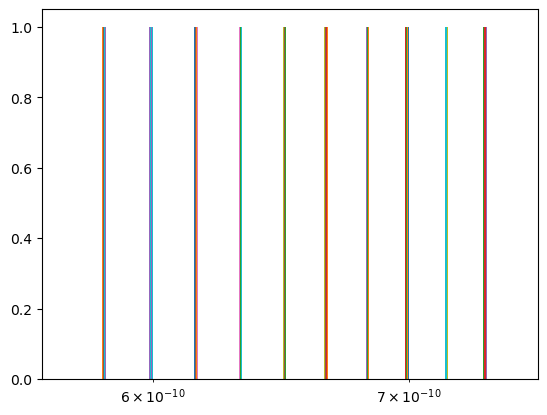

In [18]:
plt.hist(y)
plt.xscale('log')

In [19]:
y 

array([[7.48162088e-10, 7.48096325e-10, 7.48033874e-10, 7.47971098e-10,
        7.47711462e-10, 7.47650463e-10, 7.47585982e-10, 7.47521498e-10,
        7.47459802e-10, 7.47395915e-10, 7.47335489e-10, 7.47273153e-10,
        7.47208626e-10, 7.47140048e-10, 7.46890490e-10, 7.46822728e-10,
        7.46758444e-10, 7.46697363e-10, 7.46638001e-10, 7.46573692e-10,
        7.46311683e-10, 7.46247727e-10, 7.46182559e-10, 7.46124139e-10,
        7.46061688e-10, 7.45026134e-10, 7.45026134e-10, 7.44962290e-10,
        7.44896119e-10, 7.44830705e-10, 7.44760579e-10, 7.44694109e-10,
        7.44631708e-10, 7.44571348e-10, 7.44507212e-10, 7.43907325e-10,
        7.43836836e-10, 7.43570856e-10, 7.43305826e-10, 7.43305826e-10,
        7.42247768e-10, 7.42182170e-10, 7.42129652e-10, 7.42062045e-10,
        7.41997264e-10, 7.41930144e-10, 7.41868427e-10, 7.41806014e-10,
        7.41743336e-10, 7.41116574e-10, 7.40849397e-10, 7.40584297e-10,
        7.40584297e-10, 7.40516350e-10, 7.40451605e-10, 7.403864